# Benchmarking – Summary:

## 1) Imports and Set-Up:

### 1.1) Imports & Seed-Setting:

In [5]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import to_rgb

### 1.2) Helper-Functions:

In [6]:
# io – read all benchmark csvs
def _coerce_bool(s: pd.Series) -> pd.Series:
    if s.dtype == bool:
        return s
    if pd.api.types.is_numeric_dtype(s):
        return s.fillna(0).astype(int).astype(bool)
    # strings / objects
    x = s.astype(str).str.strip().str.lower()
    true_vals = {"true", "t", "1", "yes", "y"}
    false_vals = {"false", "f", "0", "no", "n"}
    out = pd.Series(np.nan, index=s.index, dtype="float")
    out[x.isin(true_vals)] = 1.0
    out[x.isin(false_vals)] = 0.0
    return out.fillna(0.0).astype(int).astype(bool)


def load_benchmark_csvs(results_dir: str | Path, pattern: str = "results_*.csv") -> pd.DataFrame:
    results_dir = Path(results_dir)
    paths = sorted(results_dir.glob(pattern))
    if not paths:
        raise FileNotFoundError(f"no files matching {pattern} in {results_dir.resolve()}")

    dfs = []
    for p in paths:
        df = pd.read_csv(p)

        stem = p.stem
        benchmark = stem[len("results_"):] if stem.startswith("results_") else stem
        df["benchmark"] = benchmark
        df["source_file"] = p.name
        dfs.append(df)

    out = pd.concat(dfs, ignore_index=True)

    for col in ["difficulty", "true_k", "k", "dataset_id"]:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce").astype("Int64")

    for col in ["is_optimal", "is_correct"]:
        if col in out.columns:
            out[col] = _coerce_bool(out[col])

    return out

def instance_key_cols(df: pd.DataFrame) -> list[str]:
    base = ["benchmark", "metric_name", "dataset_id", "true_k"]
    condition_cols = []
    for c in ["difficulty", "p", "n_samples"]: 
        if c in df.columns and df[c].notna().any():
            condition_cols.append(c)
    return base + condition_cols


# overall k-recovery summary
def wilson_ci(successes: int, n: int, z: float = 1.96) -> tuple[float, float]:
    if n <= 0:
        return (np.nan, np.nan)
    p = successes / n
    denom = 1.0 + (z**2) / n
    center = (p + (z**2) / (2 * n)) / denom
    half = (z * np.sqrt((p * (1 - p) + (z**2) / (4 * n)) / n)) / denom
    return (max(0.0, center - half), min(1.0, center + half))


def summarize_true_k_accuracy(results: pd.DataFrame) -> pd.DataFrame:
    sel = results.loc[results["is_optimal"]].copy()

    key_cols = instance_key_cols(sel)
    if sel.duplicated(key_cols).any():
        sel = sel.sort_values(key_cols + ["k"]).drop_duplicates(key_cols, keep="first")

    sel["k_error"] = (sel["k"] - sel["true_k"]).astype(float)
    sel["abs_k_error"] = sel["k_error"].abs()
    sel["over"] = sel["k_error"] > 0
    sel["under"] = sel["k_error"] < 0

    g = (
        sel.groupby("metric_name", as_index=False)
           .agg(
               n=("is_correct", "size"),
               correct=("is_correct", "sum"),
               accuracy=("is_correct", "mean"),
               mae_k=("abs_k_error", "mean"),
               bias_k=("k_error", "mean"),
               over_rate=("over", "mean"),
               under_rate=("under", "mean"),
           )
    )

    ci = [wilson_ci(int(r.correct), int(r.n)) for r in g.itertuples(index=False)]
    g["acc_ci_low"] = [c[0] for c in ci]
    g["acc_ci_high"] = [c[1] for c in ci]
    g["accuracy_ci"] = g.apply(
        lambda r: f"{r.accuracy:.3f} [{r.acc_ci_low:.3f}, {r.acc_ci_high:.3f}]",
        axis=1
    )

    return g.sort_values(["accuracy", "mae_k"], ascending=[False, True]).reset_index(drop=True)


# def summarize_true_k_accuracy_macro(results: pd.DataFrame) -> pd.DataFrame:
#     sel = results.loc[results["is_optimal"]].copy()
    
#     key_cols = instance_key_cols(sel)
#     if sel.duplicated(key_cols).any():
#         sel = sel.sort_values(key_cols + ["k"]).drop_duplicates(key_cols, keep="first")

#     sel["k_error"] = (sel["k"] - sel["true_k"]).astype(float)
#     sel["abs_k_error"] = sel["k_error"].abs()
#     sel["over"] = sel["k_error"] > 0
#     sel["under"] = sel["k_error"] < 0

#     per_bench = (
#         sel.groupby(["benchmark", "metric_name"], as_index=False)
#            .agg(
#                acc=("is_correct", "mean"),
#                mae=("abs_k_error", "mean"),
#                bias=("k_error", "mean"),
#                over_rate=("over", "mean"),
#                under_rate=("under", "mean"),
#            )
#     )

#     macro = (
#         per_bench.groupby("metric_name", as_index=False)
#                  .agg(
#                      benchmarks=("benchmark", "nunique"),
#                      acc_macro=("acc", "mean"),
#                      acc_macro_sd=("acc", "std"),
#                      mae_macro=("mae", "mean"),
#                      bias_macro=("bias", "mean"),
#                      over_rate_macro=("over_rate", "mean"),
#                      under_rate_macro=("under_rate", "mean"),
#                  )
#                  .fillna({"acc_macro_sd": 0.0})
#                  .sort_values(["acc_macro", "mae_macro"], ascending=[False, True])
#                  .reset_index(drop=True)
#     )
#     return macro


def best_metric_per_benchmark(results: pd.DataFrame) -> pd.DataFrame:
    sel = results.loc[results["is_optimal"]].copy()
    
    key_cols = instance_key_cols(sel)
    if sel.duplicated(key_cols).any():
        sel = sel.sort_values(key_cols + ["k"]).drop_duplicates(key_cols, keep="first")

    sel["abs_k_error"] = (sel["k"] - sel["true_k"]).abs().astype(float)

    per = (
        sel.groupby(["benchmark", "metric_name"], as_index=False)
           .agg(
               n=("is_correct", "size"),
               accuracy=("is_correct", "mean"),
               mae_k=("abs_k_error", "mean"),
           )
    )

    winners = (
        per.sort_values(["benchmark", "accuracy", "mae_k", "metric_name"], ascending=[True, False, True, True])
           .groupby("benchmark", as_index=False)
           .head(1)
           .reset_index(drop=True)
    )
    return winners

In [7]:
PLOT_METRICS = [
    "ari_average_1se",
    "ari_generalizability_1se",
    "ari_stability_1se",
    "silhouette",
    "gap",
    "davies_bouldin",
    "calinski_harabasz",
]

PLOT_METRICS_CARVE = [
    "ari_average_1se",
    "ari_generalizability_1se",
    "ari_stability_1se",
]

PLOT_METRICS_EXT = [
    "ari_stability_1se",
    "silhouette",
    "gap",
    "davies_bouldin",
    "calinski_harabasz",
]

METRIC_COLOR = {
    "ari_average_1se":         "#E69F00",  # blue
    "ari_generalizability_1se":"#56B4E9",  # indigo
    "ari_stability_1se":       "#009E73",  # purple
    "silhouette":              "#F0E442",  # purple-magenta
    "gap":                     "#0072B2",  # magenta
    "davies_bouldin":          "#D55E00",  # pink
    "calinski_harabasz":       "#CC79A7",  # red
}

METRIC_LABEL = {
    "ari_average_1se": "ARI (avg, 1se)",
    "ari_generalizability_1se": "ARI (gen, 1se)",
    "ari_stability_1se": "ARI (stab, 1se)",
    "silhouette": "Silhouette",
    "gap": "Gap",
    "davies_bouldin": "DB",
    "calinski_harabasz": "CH",
}


def set_paper_style():
    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.18,
        "grid.linewidth": 0.6,
        "pdf.fonttype": 42, 
        "ps.fonttype": 42,
    })


def wilson_ci(successes: int, n: int, z: float = 1.96) -> tuple[float, float]:
    if n <= 0:
        return (np.nan, np.nan)
    p = successes / n
    denom = 1.0 + (z**2) / n
    center = (p + (z**2) / (2 * n)) / denom
    half = (z * np.sqrt((p * (1 - p) + (z**2) / (4 * n)) / n)) / denom
    return (max(0.0, center - half), min(1.0, center + half))


def filter_plot_metrics(results: pd.DataFrame) -> pd.DataFrame:
    return results.loc[results["metric_name"].isin(PLOT_METRICS)].copy()

---

### Overall Results:

In [8]:
from benchmarking_functions import print_summary_stats

results_dimensionality_moons = pd.read_csv("../results/results_dimensionality_moons.csv")

print_summary_stats(results_dimensionality_moons, group_col='embed_dim')


=== Accuracy (mean (SD, SE)) by embed_dim ===
embed_dim                                            127                    174                    237   \
metric_name                                                                                               
ari_average                          0.163 (0.371, 0.042)   0.200 (0.403, 0.045)   0.138 (0.347, 0.039)   
ari_average_1se                      0.150 (0.359, 0.040)  0.225 (0.420, 0.047)*   0.150 (0.359, 0.040)   
ari_average_quant                    0.150 (0.359, 0.040)   0.163 (0.371, 0.042)   0.125 (0.333, 0.037)   
ari_generalizability                0.175 (0.382, 0.043)*   0.200 (0.403, 0.045)   0.138 (0.347, 0.039)   
ari_generalizability_1se             0.163 (0.371, 0.042)   0.225 (0.420, 0.047)   0.150 (0.359, 0.040)   
ari_generalizability_quant           0.138 (0.347, 0.039)   0.138 (0.347, 0.039)   0.113 (0.318, 0.036)   
ari_stability                        0.163 (0.371, 0.042)   0.188 (0.393, 0.044)   0.125 (0.333, 

In [9]:
results = load_benchmark_csvs(results_dir="../results", pattern="results_*.csv")

overall = summarize_true_k_accuracy(results)
# overall_macro = summarize_true_k_accuracy_macro(results)
winners = best_metric_per_benchmark(results)

paper_table = overall.loc[:, ["metric_name", "accuracy_ci", "n", "bias_k", "over_rate", "under_rate"]]

display(paper_table)
# display(overall_macro)
display(winners)

,metric_name,accuracy_ci,n,bias_k,over_rate,under_rate
0,ari_stability_1se,"0.522 [0.508, 0.536]",4880,-0.678893,0.069877,0.407992
1,ari_stability_quant,"0.510 [0.496, 0.524]",4880,-0.211475,0.188320,0.301844
2,silhouette,"0.501 [0.487, 0.515]",4880,0.713320,0.410246,0.088730
3,davies_bouldin,"0.480 [0.466, 0.494]",4880,0.904303,0.460041,0.060041
4,ari_average_quant,"0.479 [0.465, 0.493]",4880,-0.253484,0.193033,0.328074
5,ari_generalizability_1se,"0.478 [0.464, 0.492]",4880,-0.728689,0.080328,0.441598
6,ari_average_1se,"0.476 [0.462, 0.490]",4880,-0.763115,0.073566,0.450000
7,ari_generalizability_quant,"0.464 [0.450, 0.478]",4880,-0.159836,0.224180,0.312090
8,ari_average,"0.402 [0.389, 0.416]",4880,-0.976434,0.065164,0.532377
9,ari_generalizability,"0.400 [0.386, 0.414]",4880,-0.961066,0.070287,0.529918


,benchmark,metric_name,n,accuracy,mae_k
0,circles_non_lin,ari_stability_1se,800,0.31250,1.28250
1,dimensionality_gaussian,davies_bouldin,800,0.99250,0.00750
2,dimensionality_moons,silhouette,80,0.21250,1.45000
3,gaussian,ari_generalizability_quant,800,0.97625,0.02750
4,moons_non_lin,ari_stability_1se,800,0.23250,1.53875
5,swiss_rolls_non_lin,ari_stability_1se,800,0.30125,1.41000
6,t_dist,silhouette,800,0.78625,0.27625


---

### Visualizations:

/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_90871/983924354.py:77: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0.10, 1, 1))


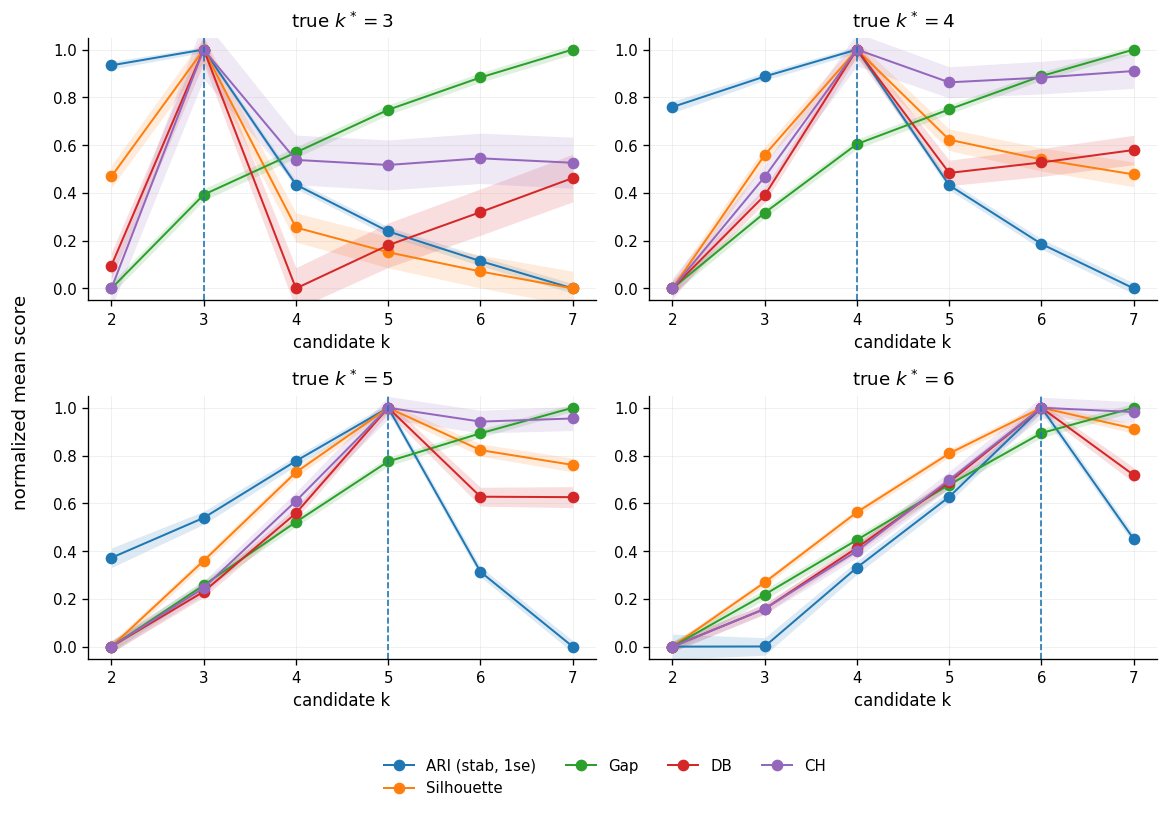

In [28]:
def plot_metric_profiles_by_true_k(
    results: pd.DataFrame,
    true_ks=(3, 4, 5, 6),
    PLOT_METRICS=PLOT_METRICS,
    show_se_band: bool = True,
    outpath: str | None = None,
):
    set_paper_style()
    df = filter_plot_metrics(results)

    agg = (
        df.groupby(["true_k", "metric_name", "k"], as_index=False)
          .agg(
              mean=("metric_value", "mean"),
              std=("metric_value", "std"),
              n=("metric_value", "size"),
          )
    )
    agg["se"] = agg["std"] / np.sqrt(agg["n"].clip(lower=1))

    # candidate ks
    ks = np.sort(df["k"].unique())

    fig, axes = plt.subplots(2, 2, figsize=(9.5, 6.8), constrained_layout=True)
    axes = axes.ravel()

    for ax, k_star in zip(axes, true_ks):
        sub = agg.loc[agg["true_k"] == k_star].copy()

        # one curve per metric
        for m in PLOT_METRICS:
            s = sub.loc[sub["metric_name"] == m].set_index("k").reindex(ks)

            y = s["mean"].to_numpy(dtype=float)
            se = s["se"].to_numpy(dtype=float)

            lo, hi = np.nanmin(y), np.nanmax(y)
            rng = hi - lo
            if not np.isfinite(rng) or rng == 0:
                y_norm = np.full_like(y, 0.5)
                se_norm = np.zeros_like(se)
            else:
                y_norm = (y - lo) / rng
                se_norm = se / rng
            y_plot, se_plot = y_norm, se_norm
            ax.set_ylim(-0.05, 1.05)

            line, = ax.plot(ks, y_plot, marker="o", linewidth=1.2, label=METRIC_LABEL[m])
            if show_se_band:
                ax.fill_between(
                    ks,
                    y_plot - se_plot,
                    y_plot + se_plot,
                    alpha=0.15,
                    linewidth=0,
                    color=line.get_color(),
                )

        ax.axvline(k_star, linestyle="--", linewidth=1.0)
        ax.set_title(r"true $k^* = %d$" % k_star)
        ax.set_xlabel("candidate k")
        ax.set_xticks(ks)

    # global legend 
    handles, labels = axes[0].get_legend_handles_labels()

    fig.text(-0.02, 0.5, "normalized mean score", va="center", rotation="vertical", fontsize=11)
    
    fig.legend(
        handles, labels,
        loc="lower center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 0),
    )
    
    fig.tight_layout(rect=(0, 0.10, 1, 1))

    if outpath is not None:
        fig.savefig(outpath, bbox_inches="tight")
    return fig


fig = plot_metric_profiles_by_true_k(results, PLOT_METRICS=PLOT_METRICS_EXT, outpath="fig_profiles_by_true_k.pdf")


/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_90871/983924354.py:77: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0.10, 1, 1))


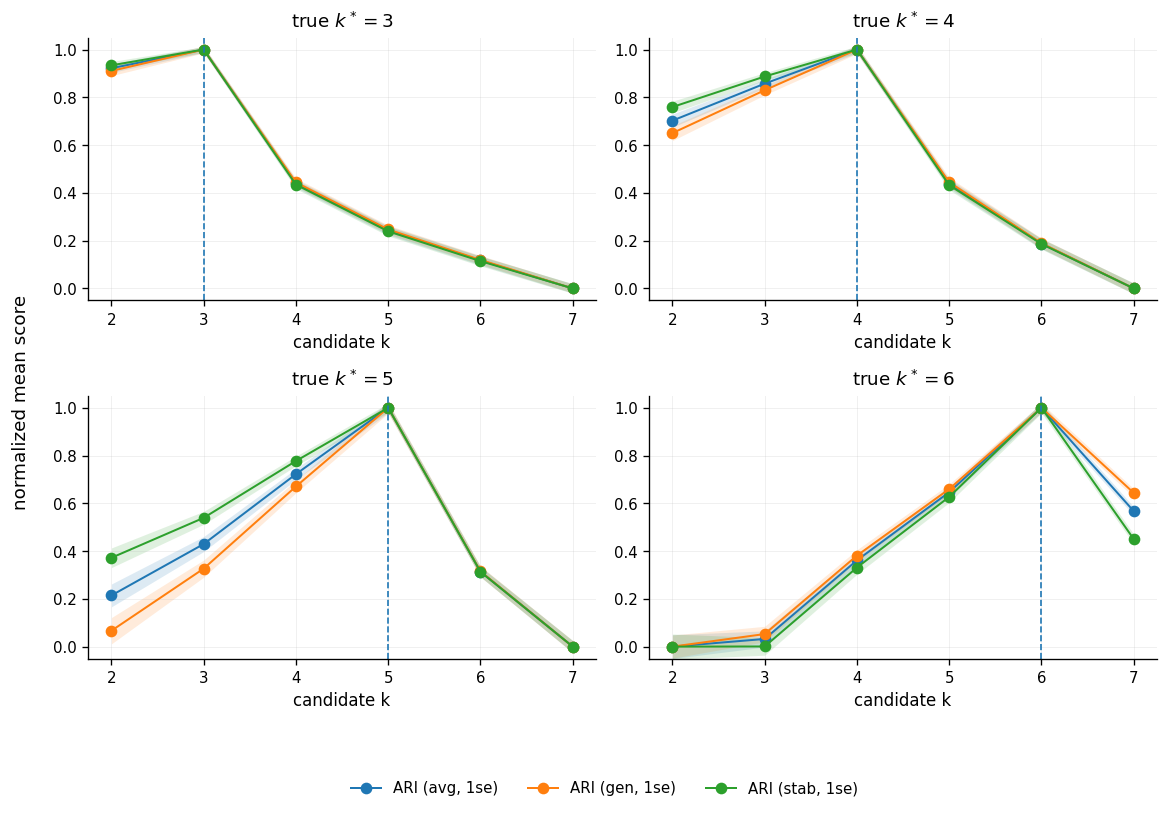

In [29]:
fig = plot_metric_profiles_by_true_k(results, PLOT_METRICS=PLOT_METRICS_CARVE, outpath="fig_profiles_by_true_k.pdf")

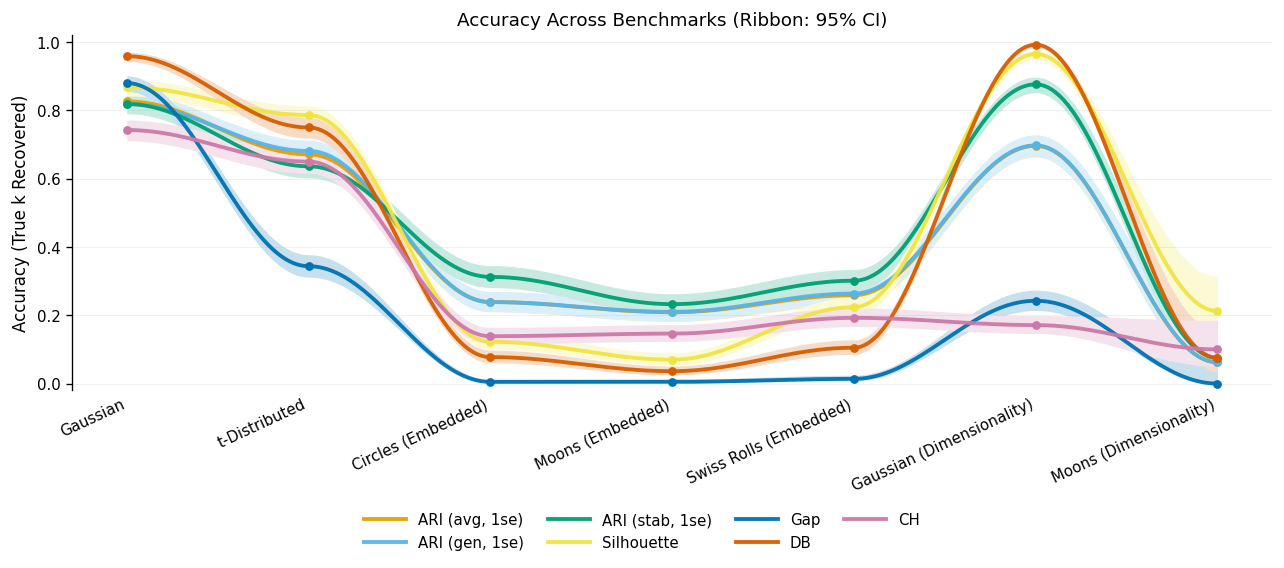

In [30]:
def instance_key_cols(df: pd.DataFrame) -> list[str]:
    base = ["benchmark", "metric_name", "dataset_id", "true_k"]
    cond = []
    for c in ["difficulty", "p"]:
        if c in df.columns and df[c].notna().any():
            cond.append(c)
    return base + cond

def accuracy_by_benchmark_with_ci(results: pd.DataFrame) -> pd.DataFrame:
    df = filter_plot_metrics(results)
    sel = df.loc[df["is_optimal"]].copy()

    key_cols = instance_key_cols(sel)
    if sel.duplicated(key_cols).any():
        sel = sel.sort_values(key_cols + ["k"]).drop_duplicates(key_cols, keep="first")

    out = (
        sel.groupby(["benchmark", "metric_name"], as_index=False)
           .agg(n=("is_correct", "size"), correct=("is_correct", "sum"))
    )
    out["accuracy"] = out["correct"] / out["n"].clip(lower=1)

    ci = [wilson_ci(int(r.correct), int(r.n)) for r in out.itertuples(index=False)]
    out["ci_low"] = [c[0] for c in ci]
    out["ci_high"] = [c[1] for c in ci]
    return out

def pastel_of(color, mix=0.72):
    r, g, b = to_rgb(color)
    return (r + (1 - r) * mix, g + (1 - g) * mix, b + (1 - b) * mix)

def _ease_interp(xi, yi, xfine):
    yfine = np.empty_like(xfine, dtype=float)
    for i in range(len(xi) - 1):
        m = (xfine >= xi[i]) & (xfine <= xi[i+1])
        t = (xfine[m] - xi[i]) / (xi[i+1] - xi[i])
        w = 0.5 - 0.5 * np.cos(np.pi * t)  # ease-in-out
        yfine[m] = (1 - w) * yi[i] + w * yi[i+1]
    yfine[xfine < xi[0]] = yi[0]
    yfine[xfine > xi[-1]] = yi[-1]
    return yfine

def prettify_benchmark_name(b: str) -> str:
    b = b.strip().lower().replace("-", "_")

    tags = []

    # tags / suffixes you use in filenames
    if "dimensionality" in b:
        tags.append("Dimensionality")
        b = b.replace("dimensionality_", "").replace("_dimensionality", "")

    embedded = False
    if "non_lin" in b or "nonlinear" in b or "embedded" in b:
        embedded = True
        b = b.replace("_non_lin", "").replace("_nonlinear", "").replace("_embedded", "")
    if embedded:
        tags.append("Embedded")

    # nice base names (fallback to title-case)
    base_map = {
        "swiss_rolls": "Swiss Rolls",
        "swiss_roll": "Swiss Roll",
        "gaussian": "Gaussian",
        "circles": "Circles",
        "moons": "Moons",
        "t": "t-Distributed",
        "t_dist": "t-Distributed",
        "t_distributed": "t-Distributed",
    }
    base = base_map.get(b, " ".join(w.capitalize() for w in b.split("_") if w))

    return f"{base} ({', '.join(tags)})" if tags else base

def plot_accuracy_ribbons(results, PLOT_METRICS=PLOT_METRICS, benchmark_order=None, outpath=None):
    set_paper_style()
    acc = accuracy_by_benchmark_with_ci(results)

    benchmarks = sorted(acc["benchmark"].unique()) if benchmark_order is None else benchmark_order
    x = np.arange(len(benchmarks), dtype=float)
    xfine = np.linspace(x.min(), x.max(), 700)

    fig, ax = plt.subplots(figsize=(10.8, 4.8), constrained_layout=False)

    handles = []
    labels = []

    for m in PLOT_METRICS:
        sub = acc.loc[acc["metric_name"] == m].set_index("benchmark").reindex(benchmarks)

        y  = sub["accuracy"].to_numpy(dtype=float)
        lo = sub["ci_low"].to_numpy(dtype=float)
        hi = sub["ci_high"].to_numpy(dtype=float)

        y_f  = _ease_interp(x, y,  xfine)
        lo_f = _ease_interp(x, lo, xfine)
        hi_f = _ease_interp(x, hi, xfine)

        base = METRIC_COLOR.get(m, "#4C78A8")
        band = pastel_of(base, mix=0.78)

        # ribbon
        ax.fill_between(xfine, lo_f, hi_f, color=band, alpha=1.0, linewidth=0, zorder=1)

        # centerline (this is what we put in legend)
        h, = ax.plot(xfine, y_f, color=base, linewidth=2.3, alpha=0.95, zorder=3)
        ax.scatter(x, y, color=base, s=18, zorder=4)

        handles.append(h)
        labels.append(METRIC_LABEL[m])

    pretty = [prettify_benchmark_name(b) for b in benchmarks]

    ax.set_xticks(x)
    ax.set_xticklabels(pretty, rotation=25, ha="right")
    ax.spines["bottom"].set_visible(False)
    ax.tick_params(axis="x", which="both", bottom=False, top=False, length=0, labelbottom=True)

    ax.set_ylim(-0.02, 1.02)
    ax.set_ylabel("Accuracy (True k Recovered)")
    ax.set_title("Accuracy Across Benchmarks (Ribbon: 95% CI)")

    ax.grid(axis="y", alpha=0.18)
    ax.grid(axis="x", visible=False)

    # legend below, "as usual"
    fig.legend(
        handles, labels,
        loc="lower center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 0.01),
        handlelength=2.8,
        columnspacing=1.6,
    )

    # reserve bottom margin for legend so it doesn't overlap ticks
    fig.tight_layout(rect=(0, 0.10, 1, 1))

    if outpath:
        fig.savefig(outpath, bbox_inches="tight")
    return fig


benchmark_order = [
    "gaussian",
    "t_dist",
    # "circles",
    # "moons",
    # "swiss_roll",
    "circles_non_lin",
    "moons_non_lin",
    "swiss_rolls_non_lin",
    "dimensionality_gaussian",
    "dimensionality_moons",
]

fig = plot_accuracy_ribbons(results, outpath="fig_parallel_accuracy.pdf", benchmark_order=benchmark_order)

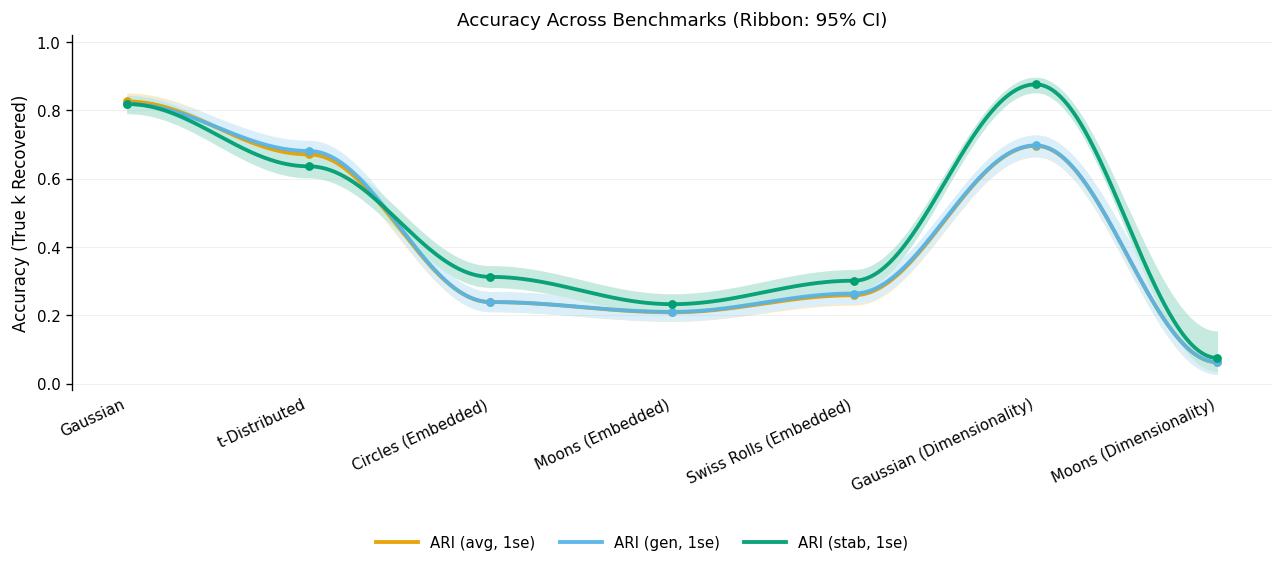

In [31]:
fig = plot_accuracy_ribbons(results, PLOT_METRICS=PLOT_METRICS_CARVE, outpath="fig_parallel_accuracy.pdf", benchmark_order=benchmark_order)

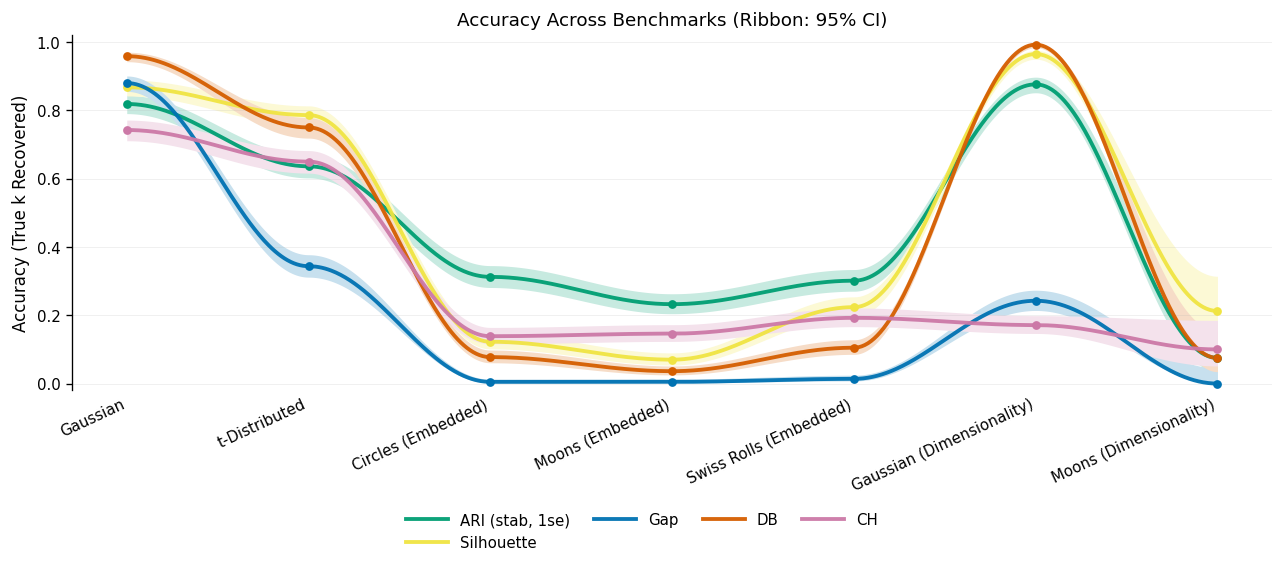

In [32]:
fig = plot_accuracy_ribbons(results, PLOT_METRICS=PLOT_METRICS_EXT, outpath="fig_parallel_accuracy.pdf", benchmark_order=benchmark_order)

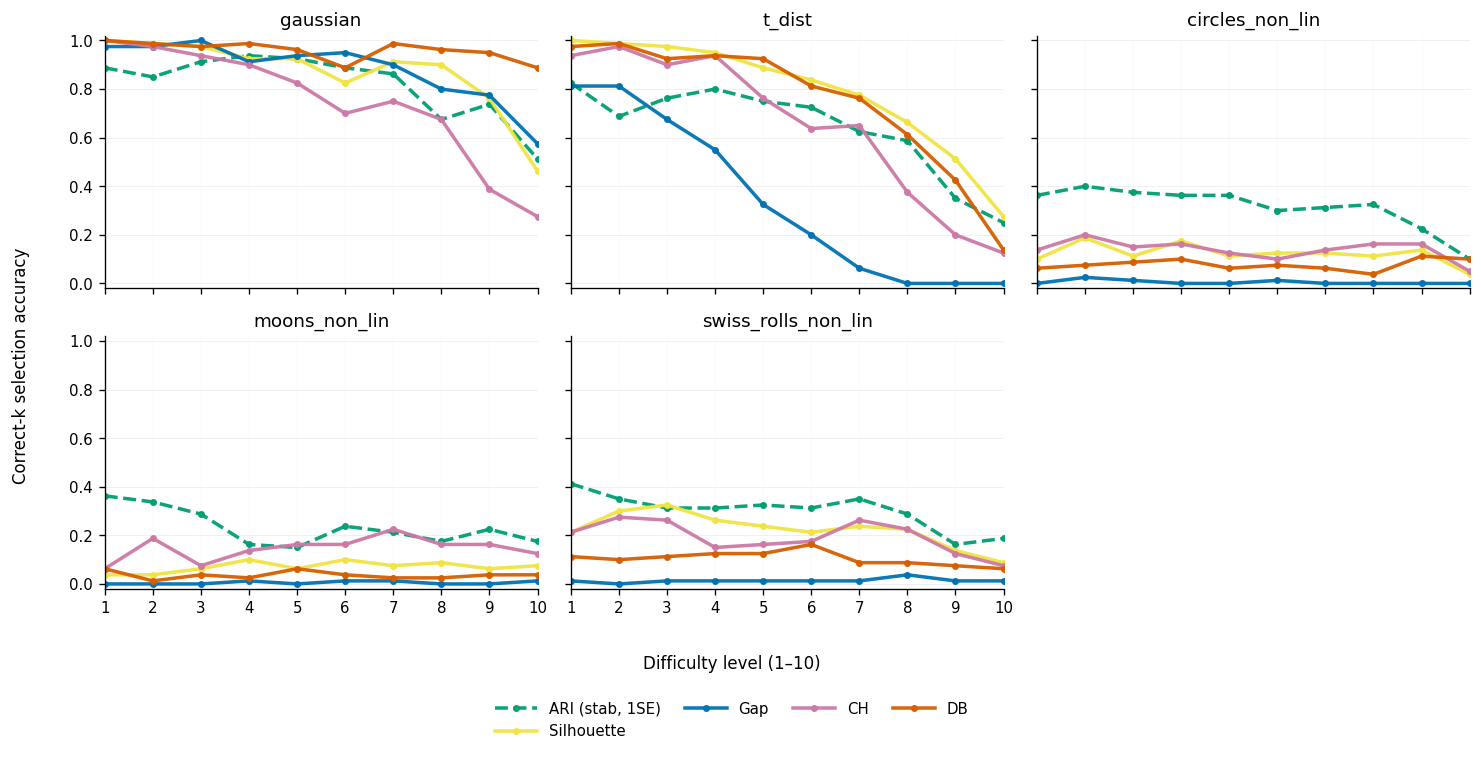

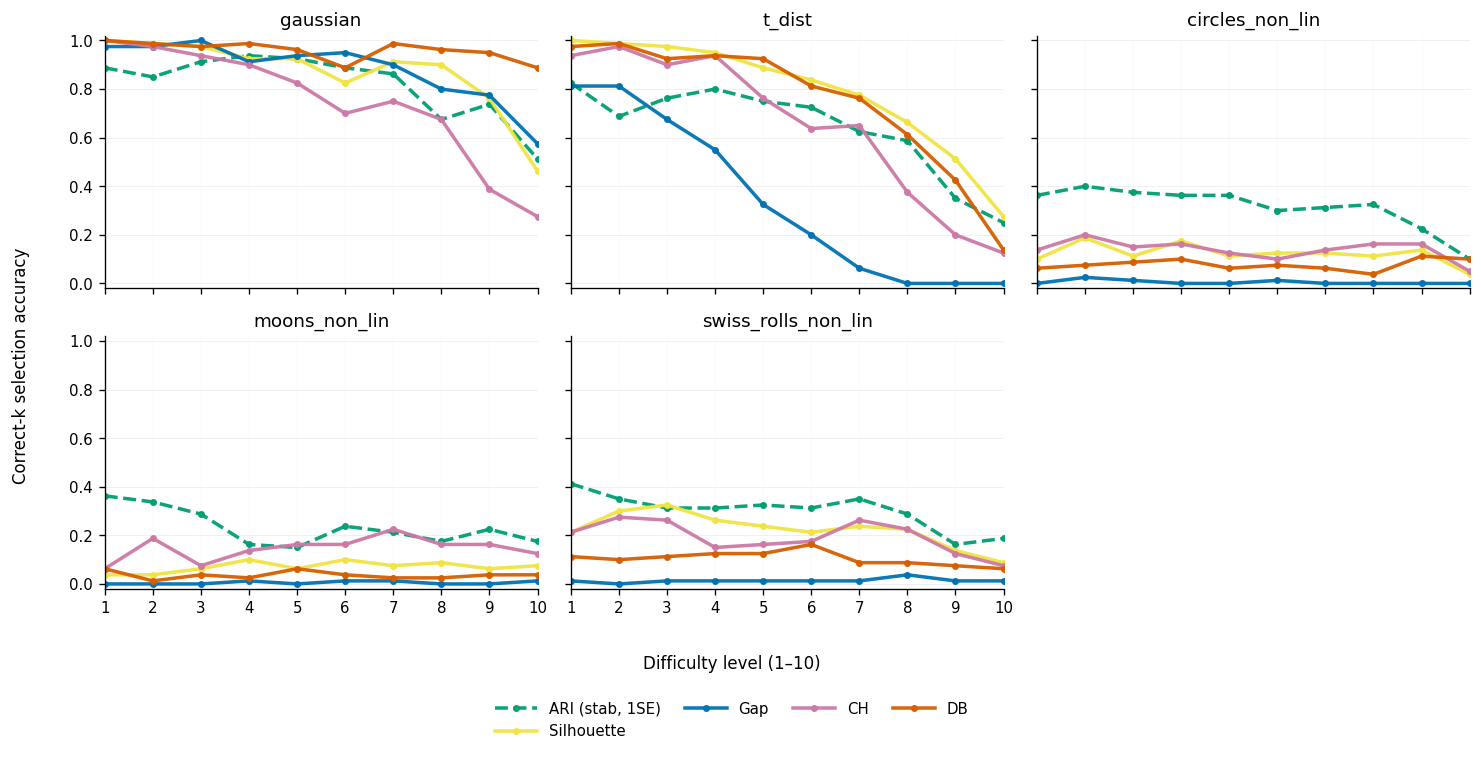

In [33]:
# Fig 6 — correct-k selection accuracy vs difficulty (one panel per simulation family)

set_paper_style()

# --- which benchmark families to show (in order) ---
# keep only families that actually have a "difficulty" ladder
benchmark_order_fig6 = [
    "gaussian",
    "t_dist",
    "circles",
    "moons",
    "swiss_roll",
    "circles_non_lin",
    "moons_non_lin",
    "swiss_rolls_non_lin",

    # t-distributed clusters + nuisance/noise dimensions (NOT RUN YET)
    # "t_dist_nuisance",
]

# --- which selectors to compare (CARVE: max + 1SE; externals: standard) ---
# metric_specs = [
#     # CARVE: stability / generalizability / avg, each with max + 1SE
#     ("ari_stability_max",           "ARI (stab, max)",  METRIC_COLOR.get("ari_stability_1se", "#009E73"), "-"),
#     ("ari_stability_1se",           "ARI (stab, 1SE)",  METRIC_COLOR.get("ari_stability_1se", "#009E73"), "--"),
#     ("ari_generalizability_max",    "ARI (gen, max)",   METRIC_COLOR.get("ari_generalizability_1se", "#56B4E9"), "-"),
#     ("ari_generalizability_1se",    "ARI (gen, 1SE)",   METRIC_COLOR.get("ari_generalizability_1se", "#56B4E9"), "--"),
#     ("ari_average_max",             "ARI (avg, max)",   METRIC_COLOR.get("ari_average_1se", "#E69F00"), "-"),
#     ("ari_average_1se",             "ARI (avg, 1SE)",   METRIC_COLOR.get("ari_average_1se", "#E69F00"), "--"),

#     # classical internal criteria
#     ("silhouette",                  "Silhouette",       METRIC_COLOR.get("silhouette", "#F0E442"), "-"),
#     ("gap",                         "Gap",              METRIC_COLOR.get("gap", "#0072B2"), "-"),
#     ("calinski_harabasz",           "CH",               METRIC_COLOR.get("calinski_harabasz", "#CC79A7"), "-"),
#     ("davies_bouldin",              "DB",               METRIC_COLOR.get("davies_bouldin", "#D55E00"), "-"),
# ]

metric_specs = [
    ("ari_stability_max", "ARI (stab, max)", METRIC_COLOR.get("ari_stability_1se", "#009E73"), "-"),
    ("ari_stability_1se", "ARI (stab, 1SE)", METRIC_COLOR.get("ari_stability_1se", "#009E73"), "--"),

#     # classical internal criteria
    ("silhouette",                  "Silhouette",       METRIC_COLOR.get("silhouette", "#F0E442"), "-"),
    ("gap",                         "Gap",              METRIC_COLOR.get("gap", "#0072B2"), "-"),
    ("calinski_harabasz",           "CH",               METRIC_COLOR.get("calinski_harabasz", "#CC79A7"), "-"),
    ("davies_bouldin",              "DB",               METRIC_COLOR.get("davies_bouldin", "#D55E00"), "-"),
]

# ---------- prep data ----------
df = results.copy()

# require difficulty ladder (this is the whole point of Fig 6)
df = df.loc[df["difficulty"].notna()].copy()

# restrict to desired benchmarks, but keep only those present
present_benchmarks = set(df["benchmark"].unique())
benchmarks = [b for b in benchmark_order_fig6 if b in present_benchmarks]
if not benchmarks:
    raise ValueError(
        "No benchmarks with a difficulty column found for the requested benchmark_order_fig6. "
        "Check your results_*.csv files contain 'difficulty' for the families you want to plot."
    )

# keep only metrics we actually have
present_metrics = set(df["metric_name"].unique())
metric_specs = [ms for ms in metric_specs if ms[0] in present_metrics]
if not metric_specs:
    raise ValueError(
        "None of the requested metric_names were found in results['metric_name']. "
        "Check naming (e.g., ari_stability_max vs ari_stability, etc.)."
    )

df = df.loc[df["benchmark"].isin(benchmarks) & df["metric_name"].isin([m for m,_,_,_ in metric_specs])].copy()

# keep only the selected k per dataset/metric (is_optimal row), and de-dup safely
sel = df.loc[df["is_optimal"]].copy()
key_cols = instance_key_cols(sel)  # already defined earlier in the notebook
if sel.duplicated(key_cols).any():
    sel = sel.sort_values(key_cols + ["k"]).drop_duplicates(key_cols, keep="first")

# aggregate accuracy over seeds within each difficulty (and across true_k values)
agg = (
    sel.groupby(["benchmark", "metric_name", "difficulty"], as_index=False)
       .agg(n=("is_correct", "size"), correct=("is_correct", "sum"))
)
agg["accuracy"] = agg["correct"] / agg["n"].clip(lower=1)

# difficulty axis: if your csvs use 0..9, shift to 1..10 for plotting
dmin = int(agg["difficulty"].min())
shift = 1 if dmin == 0 else 0
agg["difficulty_plot"] = agg["difficulty"].astype(int) + shift

# ---------- plot ----------
n = len(benchmarks)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 4.2, nrows * 3.1),
    sharex=True, sharey=True,
    constrained_layout=False,
)
axes = np.atleast_1d(axes).ravel()

handles, labels = [], []

for ax, b in zip(axes, benchmarks):
    sub_b = agg.loc[agg["benchmark"] == b].copy()

    # enforce full x-grid (1..10) so lines look consistent even if some levels missing
    xgrid = np.arange(1, 11, dtype=int)

    for metric_name, label, color, ls in metric_specs:
        sub_m = sub_b.loc[sub_b["metric_name"] == metric_name].set_index("difficulty_plot")

        y = sub_m.reindex(xgrid)["accuracy"].to_numpy(dtype=float)

        # plot
        h, = ax.plot(
            xgrid, y,
            linestyle=ls, linewidth=2.1,
            marker="o", markersize=3.2,
            color=color, alpha=0.95,
        )

        # collect legend handles once
        if b == benchmarks[0]:
            handles.append(h)
            labels.append(label)

    ax.set_title(b)
    ax.set_xlim(1, 10)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xticks(np.arange(1, 11))
    ax.grid(axis="y", alpha=0.18)
    ax.grid(axis="x", alpha=0.06)

# blank any unused axes (if n not multiple of grid)
for j in range(n, len(axes)):
    axes[j].axis("off")

# shared labels
fig.text(0.03, 0.5, "Correct-k selection accuracy", ha="center", va="center", rotation=90)

# shared labels (move x-label UP a bit)
fig.text(0.5, 0.1, "Difficulty level (1–10)", ha="center", va="center")

# legend (move legend DOWN a bit)
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02),
    handlelength=2.8,
    columnspacing=1.6,
)

# reserve more bottom space for legend + label
fig.tight_layout(rect=(0.05, 0.14, 1.00, 1.00))

# save (optional)
# fig.savefig("fig_correctk_vs_difficulty.pdf", bbox_inches="tight")

fig


In [50]:
import numpy as np
import matplotlib.pyplot as plt

def plot_accuracy_blocks(
    results,
    PLOT_METRICS=PLOT_METRICS,
    benchmark_order=None,
    outpath=None,
    *,
    ci_vline_lw=1.6,         # thickness of CI vertical line at each axis (points)
    ribbon_alpha=1.0,        # keep 1.0 for solid pastel ribbon
    band_mix=0.78,           # pastel strength
    line_width=2.3,          # accuracy polyline width
):
    set_paper_style()
    acc = accuracy_by_benchmark_with_ci(results)

    benchmarks = sorted(acc["benchmark"].unique()) if benchmark_order is None else benchmark_order
    x = np.arange(len(benchmarks), dtype=float)

    fig, ax = plt.subplots(figsize=(10.8, 4.8), constrained_layout=False)

    handles, labels = [], []

    for m in PLOT_METRICS:
        sub = acc.loc[acc["metric_name"] == m].set_index("benchmark").reindex(benchmarks)

        y  = sub["accuracy"].to_numpy(dtype=float)
        lo = sub["ci_low"].to_numpy(dtype=float)
        hi = sub["ci_high"].to_numpy(dtype=float)

        base = METRIC_COLOR.get(m, "#4C78A8")
        band = pastel_of(base, mix=band_mix)

        # --- CI ribbon between coordinates (straight-sided trapezoids) ---
        for i in range(len(x) - 1):
            if not (np.isfinite(lo[i]) and np.isfinite(hi[i]) and np.isfinite(lo[i+1]) and np.isfinite(hi[i+1])):
                continue
            ax.fill(
                [x[i], x[i+1], x[i+1], x[i]],
                [lo[i], lo[i+1], hi[i+1], hi[i]],
                color=band,
                alpha=ribbon_alpha,
                linewidth=0,
                zorder=1,
            )

        # --- CI as vertical lines at each coordinate ---
        for xi, l, h in zip(x, lo, hi):
            if not (np.isfinite(l) and np.isfinite(h)):
                continue
            ax.vlines(xi, l, h, color=band, linewidth=ci_vline_lw, zorder=2)

        # --- accuracy as straight polyline (no dots, no ticks) ---
        mask = np.isfinite(y)
        h_line, = ax.plot(
            x[mask], y[mask],
            color=base,
            linewidth=line_width,
            alpha=0.95,
            zorder=3,
        )

        handles.append(h_line)
        labels.append(METRIC_LABEL[m])

    pretty = [prettify_benchmark_name(b) for b in benchmarks]
    ax.set_xticks(x)
    ax.set_xticklabels(pretty, rotation=25, ha="right")
    ax.spines["bottom"].set_visible(False)
    ax.tick_params(axis="x", which="both", bottom=False, top=False, length=0, labelbottom=True)

    ax.set_ylim(-0.02, 1.02)
    ax.set_ylabel("Accuracy (True k Recovered)")
    ax.set_title("Accuracy Across Benchmarks (95% CI Ribbon)")

    ax.grid(axis="y", alpha=0.18)
    ax.grid(axis="x", visible=False)

    fig.legend(
        handles, labels,
        loc="lower center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 0.01),
        handlelength=2.8,
        columnspacing=1.6,
    )
    fig.tight_layout(rect=(0, 0.10, 1, 1))

    if outpath:
        fig.savefig(outpath, bbox_inches="tight")
    return fig


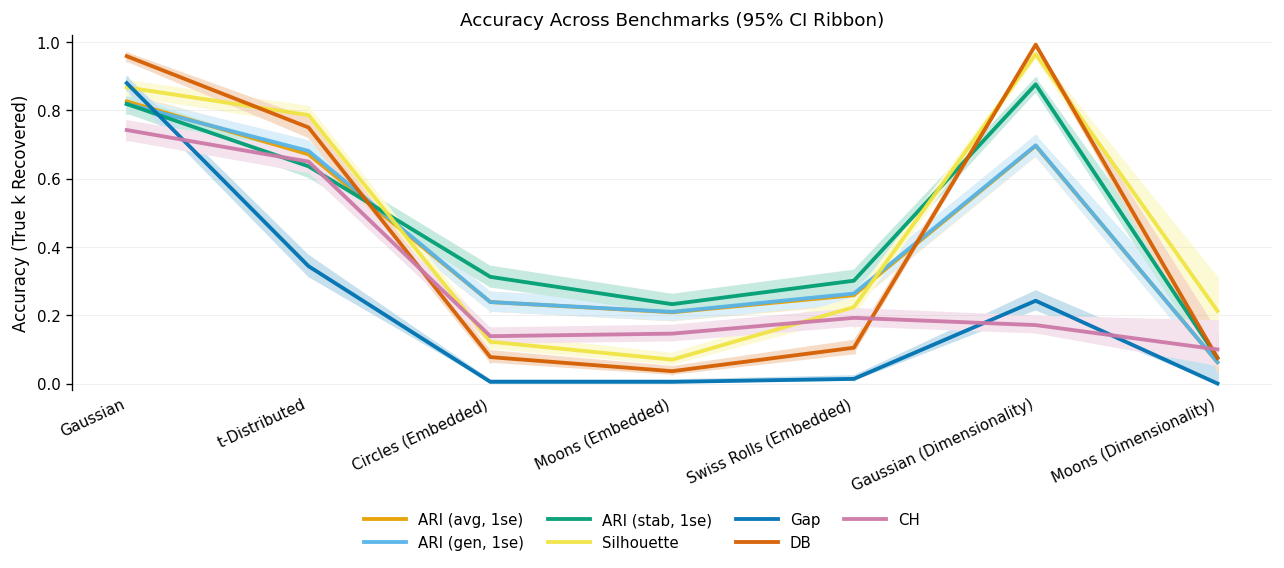

In [51]:
fig = plot_accuracy_blocks(
    results,
    outpath="fig_parallel_accuracy.pdf",
    benchmark_order=benchmark_order,
)


---

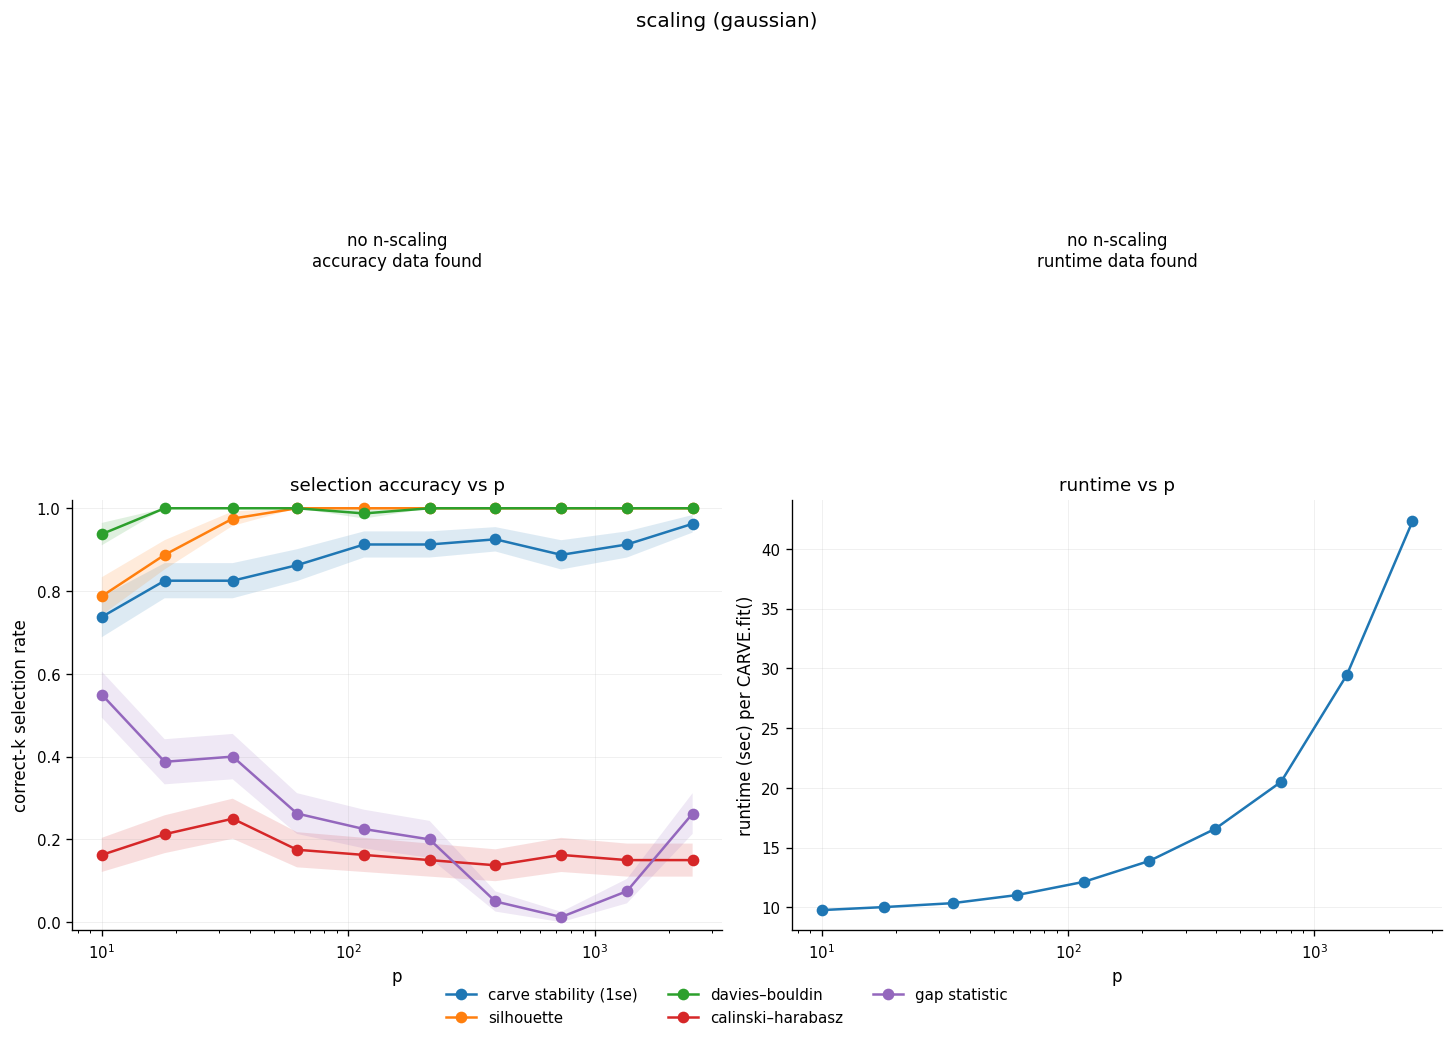

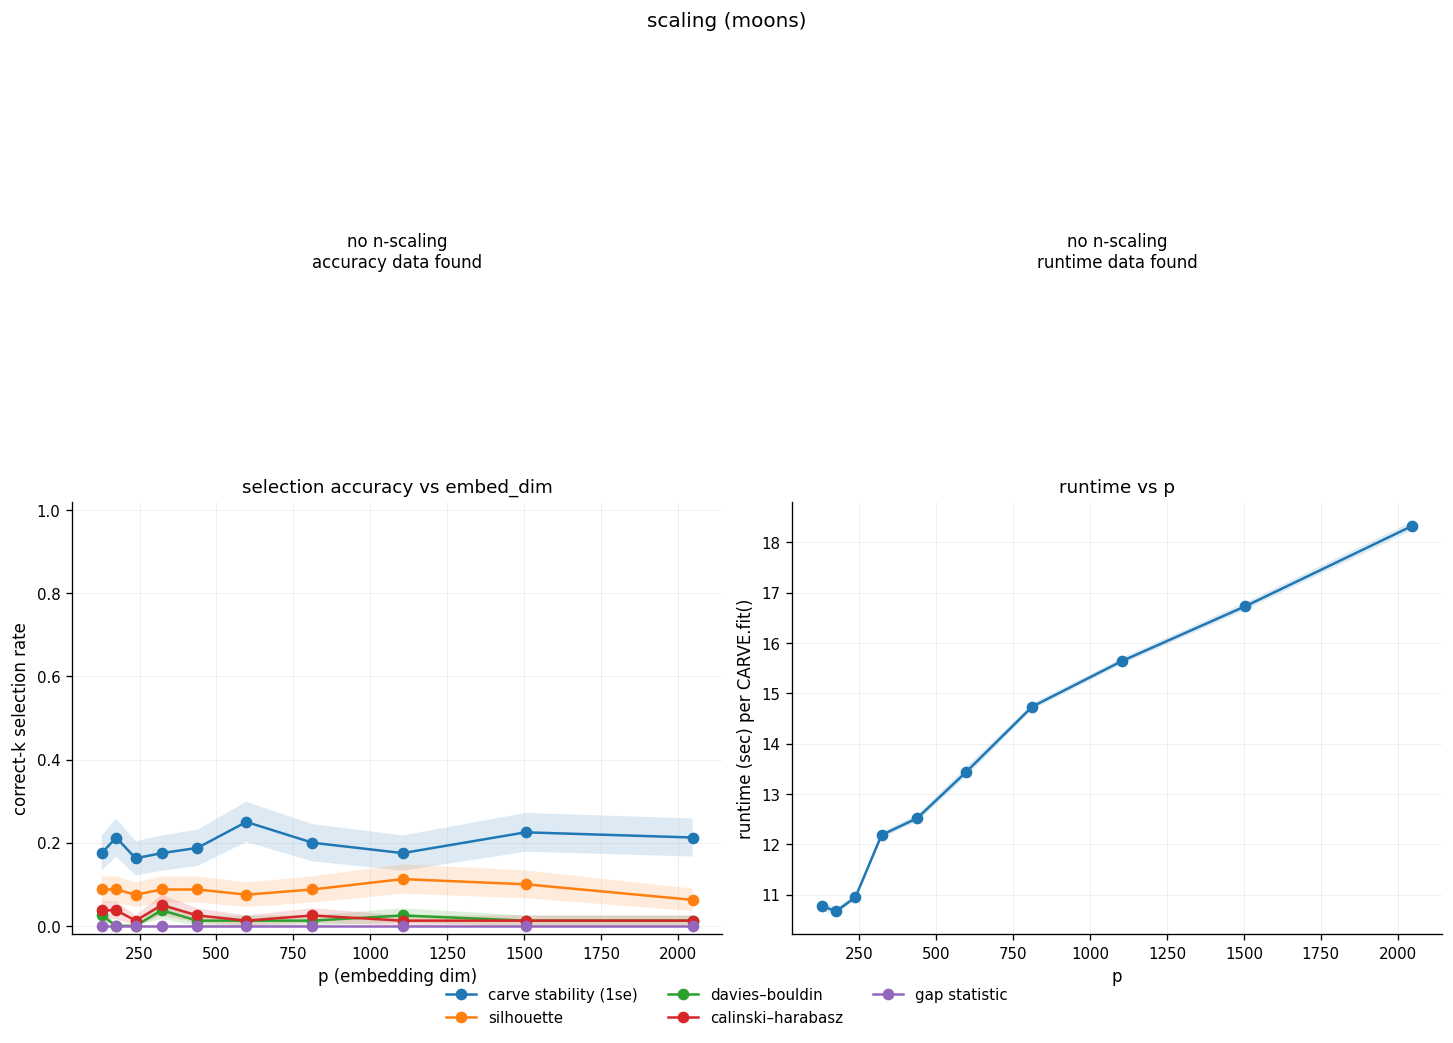

In [63]:
# --- scaling figure: selection accuracy + runtime (robust to missing n-scaling files) ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# paths (edit if needed)
ACC_FILES = {
    "gaussian": "../results/results_dimensionality_gaussian.csv",
    "moons": "../results/results_dimensionality_moons.csv",
}
RT_FILES = {
    "gaussian": "../results/runtime_dimensionality_gaussian.csv",
    "moons": "../results/runtime_dimensionality_moons.csv",
}

# choose which methods to show (trim this if the legend gets too busy)
METRICS_KEEP = [
    "ari_stability_1se",
    # "ari_generalizability_1se",
    # "ari_average_1se",
    "silhouette",
    "davies_bouldin",
    "calinski_harabasz",
    "gap",
]

LABEL_MAP = {
    "ari_stability_1se": "carve stability (1se)",
    "ari_generalizability_1se": "carve generalizability (1se)",
    "ari_average_1se": "carve average (1se)",
    "ari_stability": "carve stability (max)",
    "ari_generalizability": "carve generalizability (max)",
    "ari_average": "carve average (max)",
    "silhouette": "silhouette",
    "gap": "gap statistic",
    "davies_bouldin": "davies–bouldin",
    "calinski_harabasz": "calinski–harabasz",
}

def _pick_dim_col(df):
    # prefer explicit p; otherwise embedding dimension; otherwise error
    for c in ("p", "embed_dim", "d", "dim"):
        if c in df.columns:
            return c
    raise ValueError(f"could not find a dimension column in: {list(df.columns)}")

def _maybe_log_x(ax, x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size >= 2 and (x.max() / max(x.min(), 1e-12)) >= 20:
        ax.set_xscale("log")

def _maybe_log_y(ax, y):
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]
    y = y[y > 0]
    if y.size >= 2 and (y.max() / max(y.min(), 1e-12)) >= 50:
        ax.set_yscale("log")

def _selection_accuracy(df, xcol):
    df = df.copy()
    # normalize bool columns
    for c in ("is_optimal", "is_correct"):
        if c in df.columns and df[c].dtype != bool:
            df[c] = df[c].astype(str).str.lower().map({"true": True, "false": False}).fillna(df[c]).astype(bool)

    sel = df[df["is_optimal"]].copy()
    out = (
        sel.groupby([xcol, "metric_name"], as_index=False)
           .agg(acc=("is_correct", "mean"), n=("is_correct", "size"))
    )
    # binomial se (selection accuracy is a proportion)
    out["se"] = np.sqrt(out["acc"] * (1 - out["acc"]) / out["n"].clip(lower=1))
    return out

def _runtime_summary(df, xcol, time_col="t_carve_sec"):
    out = (
        df.groupby(xcol, as_index=False)[time_col]
          .agg(mean="mean", sd="std", n="size")
    )
    out["se"] = out["sd"] / np.sqrt(out["n"].clip(lower=1))
    return out

def plot_scaling_figure(acc_path, rt_path, *, title="", metrics_keep=METRICS_KEEP, time_col="t_carve_sec"):
    acc = pd.read_csv(acc_path)
    rt = pd.read_csv(rt_path)

    pcol_acc = _pick_dim_col(acc)
    pcol_rt  = _pick_dim_col(rt)

    ncol_acc = "n" if "n" in acc.columns else None
    ncol_rt  = "n" if "n" in rt.columns else None

    # figure layout: left column = accuracy (vs n, vs p); right column = runtime (vs n, vs p)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
    (ax_acc_n, ax_rt_n), (ax_acc_p, ax_rt_p) = axes

    # ---- accuracy vs n (p fixed) ----
    if ncol_acc is not None and acc[ncol_acc].nunique() > 1:
        # if p varies too, fix it at the modal value
        df_n = acc
        if acc[pcol_acc].nunique() > 1:
            p_fixed = acc[pcol_acc].mode().iloc[0]
            df_n = acc[acc[pcol_acc] == p_fixed]
            ax_acc_n.set_title(f"selection accuracy vs n (fixed {pcol_acc}={p_fixed})")
        else:
            ax_acc_n.set_title("selection accuracy vs n")

        out_n = _selection_accuracy(df_n, ncol_acc)
        for m in metrics_keep:
            sub = out_n[out_n["metric_name"] == m].sort_values(ncol_acc)
            if sub.empty:
                continue
            ax_acc_n.plot(sub[ncol_acc], sub["acc"], marker="o", label=LABEL_MAP.get(m, m))
            ax_acc_n.fill_between(sub[ncol_acc], sub["acc"] - sub["se"], sub["acc"] + sub["se"], alpha=0.15)
        ax_acc_n.set_xlabel("n (samples)")
        ax_acc_n.set_ylabel("correct-k selection rate")
        ax_acc_n.set_ylim(-0.02, 1.02)
        _maybe_log_x(ax_acc_n, out_n[ncol_acc].unique())
    else:
        ax_acc_n.axis("off")
        ax_acc_n.text(0.5, 0.5, "no n-scaling\naccuracy data found", ha="center", va="center")

    # ---- accuracy vs p (n fixed) ----
    df_p = acc
    if ncol_acc is not None and acc[ncol_acc].nunique() > 1:
        n_fixed = acc[ncol_acc].mode().iloc[0]
        df_p = acc[acc[ncol_acc] == n_fixed]
        ax_acc_p.set_title(f"selection accuracy vs {pcol_acc} (fixed n={n_fixed})")
    else:
        ax_acc_p.set_title(f"selection accuracy vs {pcol_acc}")

    out_p = _selection_accuracy(df_p, pcol_acc)
    for m in metrics_keep:
        sub = out_p[out_p["metric_name"] == m].sort_values(pcol_acc)
        if sub.empty:
            continue
        ax_acc_p.plot(sub[pcol_acc], sub["acc"], marker="o", label=LABEL_MAP.get(m, m))
        ax_acc_p.fill_between(sub[pcol_acc], sub["acc"] - sub["se"], sub["acc"] + sub["se"], alpha=0.15)
    ax_acc_p.set_xlabel(pcol_acc if pcol_acc != "embed_dim" else "p (embedding dim)")
    ax_acc_p.set_ylabel("correct-k selection rate")
    ax_acc_p.set_ylim(-0.02, 1.02)
    _maybe_log_x(ax_acc_p, out_p[pcol_acc].unique())

    # ---- runtime vs n (p fixed) ----
    if ncol_rt is not None and rt[ncol_rt].nunique() > 1:
        df_nrt = rt
        if rt[pcol_rt].nunique() > 1:
            p_fixed = rt[pcol_rt].mode().iloc[0]
            df_nrt = rt[rt[pcol_rt] == p_fixed]
            ax_rt_n.set_title(f"runtime vs n (fixed {pcol_rt}={p_fixed})")
        else:
            ax_rt_n.set_title("runtime vs n")

        r_n = _runtime_summary(df_nrt, ncol_rt, time_col=time_col)
        r_n = r_n.sort_values(ncol_rt)
        ax_rt_n.plot(r_n[ncol_rt], r_n["mean"], marker="o")
        ax_rt_n.fill_between(r_n[ncol_rt], r_n["mean"] - r_n["se"], r_n["mean"] + r_n["se"], alpha=0.15)
        ax_rt_n.set_xlabel("n (samples)")
        ax_rt_n.set_ylabel("runtime (sec) per CARVE.fit()")
        _maybe_log_x(ax_rt_n, r_n[ncol_rt].unique())
        _maybe_log_y(ax_rt_n, r_n["mean"].values)
    else:
        ax_rt_n.axis("off")
        ax_rt_n.text(0.5, 0.5, "no n-scaling\nruntime data found", ha="center", va="center")

    # ---- runtime vs p (n fixed) ----
    df_prt = rt
    if ncol_rt is not None and rt[ncol_rt].nunique() > 1:
        n_fixed = rt[ncol_rt].mode().iloc[0]
        df_prt = rt[rt[ncol_rt] == n_fixed]
        ax_rt_p.set_title(f"runtime vs {pcol_rt} (fixed n={n_fixed})")
    else:
        ax_rt_p.set_title(f"runtime vs {pcol_rt}")

    r_p = _runtime_summary(df_prt, pcol_rt, time_col=time_col).sort_values(pcol_rt)
    ax_rt_p.plot(r_p[pcol_rt], r_p["mean"], marker="o")
    ax_rt_p.fill_between(r_p[pcol_rt], r_p["mean"] - r_p["se"], r_p["mean"] + r_p["se"], alpha=0.15)
    ax_rt_p.set_xlabel(pcol_rt if pcol_rt != "embed_dim" else "p (embedding dim)")
    ax_rt_p.set_ylabel("runtime (sec) per CARVE.fit()")
    _maybe_log_x(ax_rt_p, r_p[pcol_rt].unique())
    _maybe_log_y(ax_rt_p, r_p["mean"].values)

    # shared legend (from accuracy plots)
    handles, labels = ax_acc_p.get_legend_handles_labels()
    if handles:
        fig.legend(
            handles, labels,
            loc="lower center",
            bbox_to_anchor=(0.5, -0.05),   # move legend down
            ncol=min(3, len(labels)),
            frameon=False
        )

    if title:
        fig.suptitle(title, y=1.02)

    return fig, axes

# --- run for both families (comment out whichever you don't want) ---
fig1, _ = plot_scaling_figure(ACC_FILES["gaussian"], RT_FILES["gaussian"], title="scaling (gaussian)")
fig2, _ = plot_scaling_figure(ACC_FILES["moons"], RT_FILES["moons"], title="scaling (moons)")

plt.show()

# optional: save
# fig1.savefig("scaling_gaussian.png", dpi=300, bbox_inches="tight")
# fig2.savefig("scaling_moons.png", dpi=300, bbox_inches="tight")
